# Smell and Weather Correlation Analysis

This notebook analyzes the relationship and correlation between smell reports and various weather variables: **temperature**, **pressure**, and **wind speed**.

In [1]:
# Display the current Python environment details and search path
import sys
print(f"Python Path: {sys.executable}")
print(f"Searching in: {sys.path}")


Python Path: /Library/Frameworks/Python.framework/Versions/3.14/bin/python3
Searching in: ['/Library/Frameworks/Python.framework/Versions/3.14/lib/python314.zip', '/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14', '/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/lib-dynload', '', '/Users/nawrig04/Library/Python/3.14/lib/python/site-packages', '/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages']


In [2]:
# Import essential libraries for data analysis and visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Path to the cleaned weather and smell reports dataset
csv_path = "Louisville Data/open-meteo-smell-merged.csv"


## 1. Load and Clean the Dataset

We load the cleaned dataset using `pandas`. Column names are stripped of any leading/trailing spaces.

In [3]:
# Load the cleaned dataset, strip trailing spaces from column names, and display preview
try:
    df = pd.read_csv(csv_path, low_memory=False)
    # Clean column headers by stripping leading/trailing whitespace
    df.columns = df.columns.str.strip()
    # Rename columns from open-meteo merged format to legacy format
    rename_dict = {
        'temperature_2m (°F)': 'temperature',
        'surface_pressure (hPa)': 'pressure',
        'wind_speed_10m (mp/h)': 'wind_speed'
    }
    df = df.rename(columns=rename_dict)
    print("Dataset preview:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: Cleaned dataset file not found at: {csv_path}")


Dataset preview:


,location_id,latitude,longitude,zipcode,time,temperature,relative_humidity_2m (%),dew_point_2m (°F),pressure,wind_speed,...,boundary_layer_height (ft),shortwave_radiation (W/m²),datetime_utc,datetime_local,smell_report_count,smell_value_average,smell_value_max,smell_descriptions,smell_symptoms,smell_comments
0,10,38.235806,-85.816335,40211,2017-12-31T19:00,14.4,47,-2.3,1018.0,9.2,...,12432.316671,0.0,2018-01-01 00:00:00+00:00,2017-12-31 19:00:00-05:00,0,NaN,NaN,NaN,NaN,NaN
1,10,38.235806,-85.816335,40211,2017-12-31T20:00,13.7,48,-2.3,1018.7,8.5,...,11840.302216,0.0,2018-01-01 01:00:00+00:00,2017-12-31 20:00:00-05:00,0,NaN,NaN,NaN,NaN,NaN
2,10,38.235806,-85.816335,40211,2017-12-31T21:00,12.9,52,-1.6,1019.1,8.2,...,10225.715550,0.0,2018-01-01 02:00:00+00:00,2017-12-31 21:00:00-05:00,0,NaN,NaN,NaN,NaN,NaN
3,10,38.235806,-85.816335,40211,2017-12-31T22:00,11.8,56,-0.7,1019.6,8.4,...,9256.962238,0.0,2018-01-01 03:00:00+00:00,2017-12-31 22:00:00-05:00,0,NaN,NaN,NaN,NaN,NaN
4,10,38.235806,-85.816335,40211,2017-12-31T23:00,10.7,60,-0.6,1019.9,7.7,...,7588.556673,0.0,2018-01-01 04:00:00+00:00,2017-12-31 23:00:00-05:00,0,NaN,NaN,NaN,NaN,NaN


## 2. Statistical Correlation Matrix

Calculate the Pearson correlation coefficients between the number of smell reports and the various weather metrics.

In [4]:
# Calculate Pearson correlation matrix focusing specifically on smell reports and weather variables
correlation_matrix = df[['smell_report_count', 'temperature', 'pressure', 'wind_speed']].corr()

print("Correlation of weather variables with respect to smell reports:")
display(correlation_matrix['smell_report_count'].sort_values(ascending=False))


Correlation of weather variables with respect to smell reports:


smell_report_count    1.000000
pressure              0.016044
temperature           0.012173
wind_speed           -0.008649
Name: smell_report_count, dtype: float64

## 3. Visualization: Correlation Heatmap

Plotting a heatmap of the correlation matrix to visualize patterns.

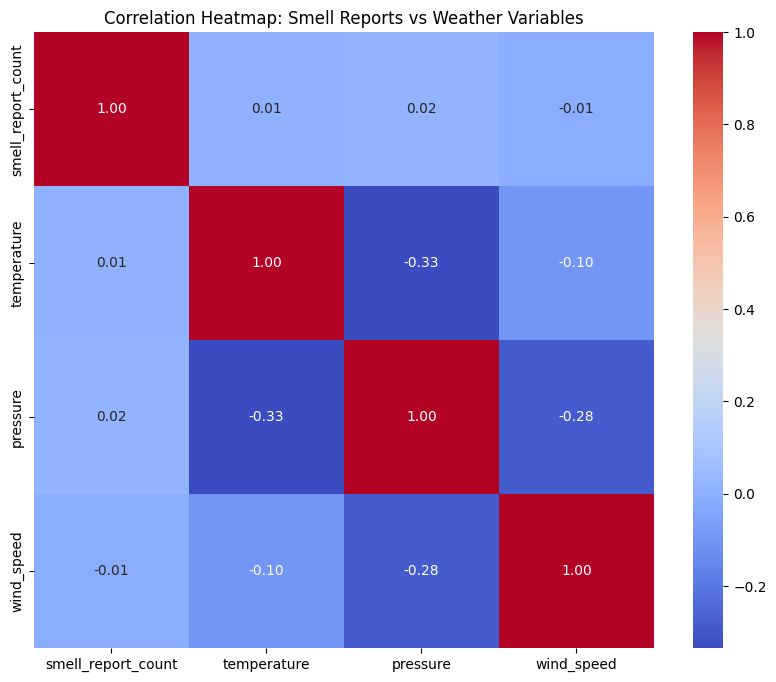

In [5]:
# Generate a correlation heatmap using Seaborn to visualize relationships
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Smell Reports vs Weather Variables')
plt.show()


## 4. Scatter Plots with Regression Lines

Generate regression plots for each weather variable to check for linearity and calculate $p$-values for statistical significance.

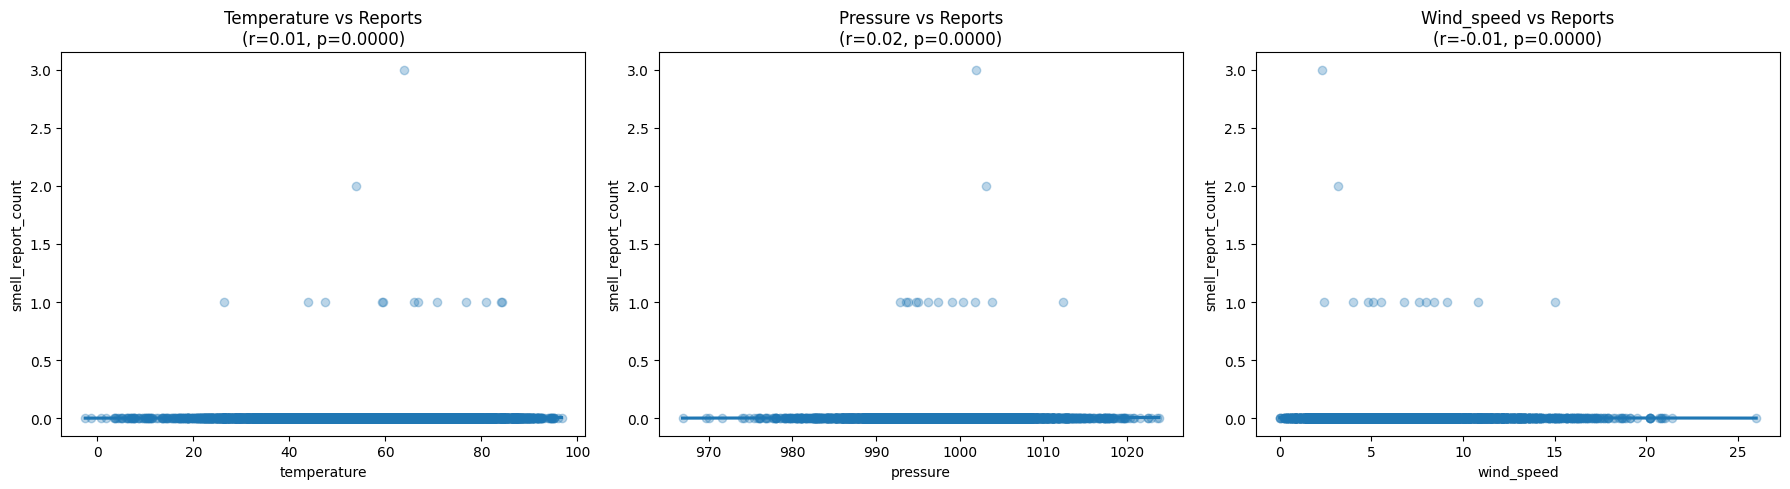

In [6]:
# Define weather variables of interest
variables = ['temperature', 'pressure', 'wind_speed']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Iterate through variables to generate scatter plots with linear regression lines
for i, var in enumerate(variables):
    # Plot regression line using Seaborn regplot
    sns.regplot(ax=axes[i], x=var, y='smell_report_count', data=df.sample(n=min(len(df), 5000), random_state=42), scatter_kws={'alpha':0.3}, ci=None)
    
    # Calculate Pearson correlation coefficient (r) and two-tailed p-value
    corr_val, p_val = pearsonr(df[var], df['smell_report_count'])
    axes[i].set_title(f'{var.capitalize()} vs Reports\n(r={corr_val:.2f}, p={p_val:.4f})')

plt.tight_layout()
plt.show()
